# Predicting U.S. bank failures from FDIC data

Classification of U.S. banks into failed / non-failed using bank-level financial ratios (from Call Reports) and macroeconomic variables, comparing:

1. Logistic regression (statsmodels), with p-values used to select a reduced set of predictors
2. L1-regularised logistic regression (scikit-learn), on the full and on the reduced predictor sets
3. Logistic regression trained by mini-batch gradient descent (TensorFlow 1.x)
4. A two-hidden-layer neural network (TensorFlow 1.x)

Models are evaluated with accuracy, precision/recall, ROC AUC and the Kolmogorov–Smirnov statistic.

*Based on an assignment from the Coursera course "Guided Tour of Machine Learning in Finance" (NYU Tandon).*

**Environment:** Python 3.6, scikit-learn 0.18+, statsmodels, TensorFlow 1.x (the TensorFlow sections use the 1.x graph API and do not run on TensorFlow 2).

**Data:** the notebook expects the course's preprocessed HDF5 files in `data/`. They are not included in this repository.

In [ ]:
%pip install -r requirements

In [88]:
import numpy as np
import pandas as pd
import sklearn


try:
    import matplotlib.pyplot as plt
    %matplotlib inline
except ImportError:
    pass
print('scikit-learn version:', sklearn.__version__)

scikit-learn version: 1.9.1


In [89]:
# Predictor groups
state_cols = ['log_TA','NI_to_TA', 'Equity_to_TA', 'NPL_to_TL', 'REO_to_TA', 
              'ALLL_to_TL', 'core_deposits_to_TA', 'brokered_deposits_to_TA', 
              'liquid_assets_to_TA', 'loss_provision_to_TL', 'NIM', 'assets_growth']

all_MEVs = np.array(['term_spread',
                    'stock_mkt_growth',
                    'real_gdp_growth',
                    'unemployment_rate_change',
                    'treasury_yield_3m',
                    'bbb_spread',
                    'bbb_spread_change'])

MEV_cols = all_MEVs.tolist()

next_state_cols = ['log_TA_plus_1Q','NI_to_TA_plus_1Q', 'Equity_to_TA_plus_1Q', 'NPL_to_TL_plus_1Q', 'REO_to_TA_plus_1Q', 
                   'ALLL_to_TL_plus_1Q', 'core_deposits_to_TA_plus_1Q', 'brokered_deposits_to_TA_plus_1Q', 
                   'liquid_assets_to_TA_plus_1Q', 'loss_provision_to_TL_plus_1Q', 
                   'ROA_plus_1Q', 
                   'NIM_plus_1Q', 
                   'assets_growth_plus_1Q', 
                   'FDIC_assessment_base_plus_1Q_n']

In [90]:
df_train = pd.read_hdf('data/df_train_FDIC_defaults_1Y.h5', key='df')
df_test = pd.read_hdf('data/df_test_FDIC_defaults_1Y.h5', key='df')
print('train:', df_train.shape, ' test:', df_test.shape)
df_train.head()

train: (641, 44)  test: (331, 44)


,,Financial Institution Name,Institution Name,total_assets,defaulter,Failure / Assistance,log_TA,NI_to_TA,Equity_to_TA,NPL_to_TL,REO_to_TA,...,loss_provision_to_TL_plus_1Q,ROA_plus_1Q,NIM_plus_1Q,assets_growth_plus_1Q,default_within_1Y,Failure,max_total_assets,num_records,non_defaulter,const
IDRSSD,date,,,,,,,,,,,,,,,,,,,,,
904957,2008-03-31,COLORADO NATIONAL BANK,COLORADO NATIONAL BANK,142138.0,1.0,FAILURE,-0.048734,-6.505183,-0.759562,0.880756,-0.162301,...,0.004823,-0.367905,-0.840312,-0.582232,1.0,1.0,142138.0,31.0,0.0,1
202907,2011-06-30,"COMMUNITY BANK, NATIONAL ASSOCIATION",NaN,6364903.0,0.0,NaN,2.754852,0.143005,0.249275,-0.405931,-0.327268,...,-0.003057,0.205816,-0.140365,0.003962,0.0,NaN,8494486.0,60.0,1.0,1
652874,2012-12-31,"NEXBANK, SSB",NaN,784781.0,0.0,NaN,1.211269,0.229021,-0.301031,-0.750449,-0.304600,...,-0.003506,0.470935,-0.799310,0.284815,0.0,NaN,2698563.0,60.0,1.0,1
9115,2003-03-31,COMMERCE BANK/SHORE NATIONAL ASSOCIATION,NaN,2173481.0,0.0,NaN,1.962490,0.253469,-0.922810,-0.752942,-0.374868,...,-0.002819,0.225454,-0.324276,1.091618,0.0,NaN,2697759.0,12.0,1.0,1
3344611,2012-06-30,"BANK OF AMERICA RHODE ISLAND, NATIONAL ASSOCIA...",NaN,19405460.0,1.0,NaN,3.576923,0.103615,0.088508,2.380231,-0.121243,...,0.001903,0.101099,-0.791229,-0.408817,0.0,NaN,39211041.0,31.0,0.0,1


## Exploratory analysis

<Axes: xlabel='log_TA', ylabel='defaulter'>

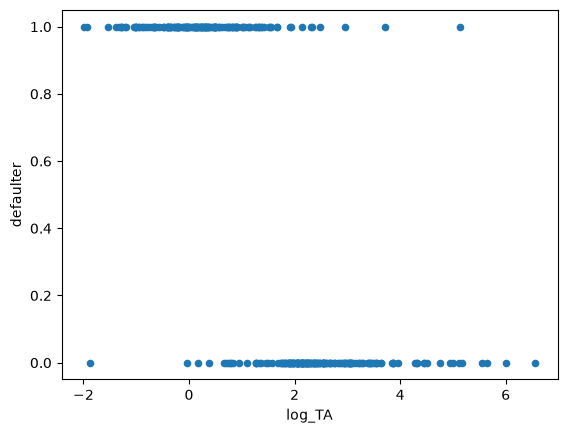

In [91]:
df_test.plot(x=state_cols[0], y='defaulter', kind='scatter')

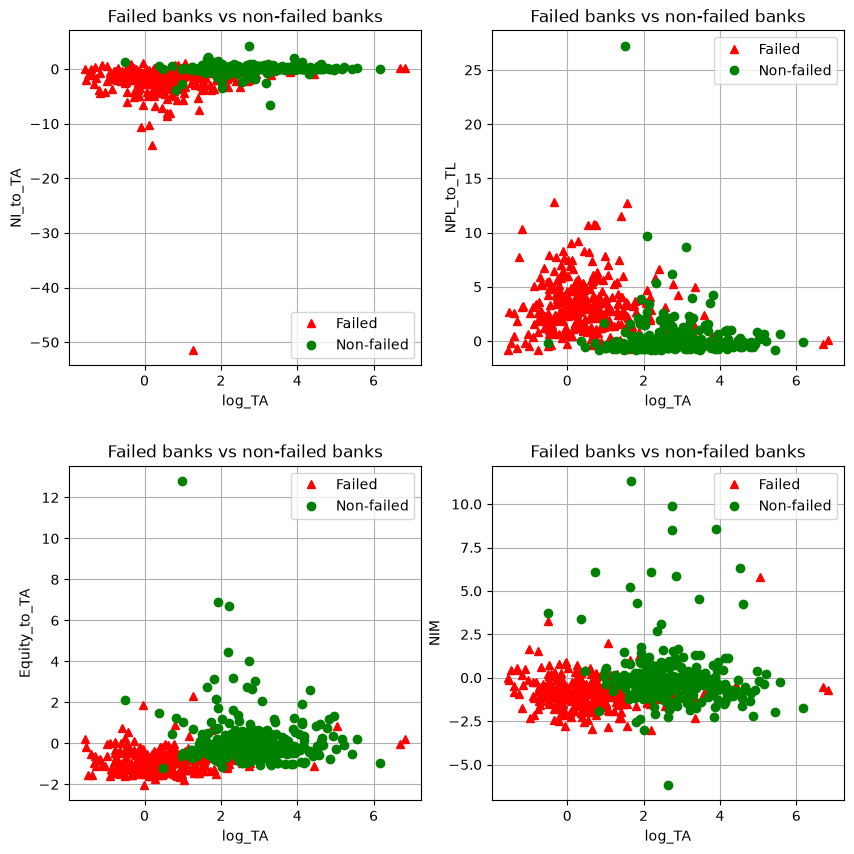

In [92]:
# Plot 4 scatter plots together

# log_TA / NI_to_TA
# log_TA / NPL_to_TL
# log_TA / Equity_to_TA
# log_TA / NIM

first_indx = [0, 0, 0, 0]
second_indx = [1, 3, 2, 10]

X_train = df_train[state_cols].values
y_train = df_train.defaulter.values # .reshape(-1,1)

num_plots = 4
if num_plots % 2 == 0:
    f, axs = plt.subplots(num_plots // 2, 2)
else:
    f, axs = plt.subplots(num_plots// 2 + 1, 2)
    
f.subplots_adjust(hspace=.3)

f.set_figheight(10.0)
f.set_figwidth(10.0)
    
for i in range(num_plots):
    if i % 2 == 0:
        first_idx = i // 2
        second_idx = 0
    else:
        first_idx = i // 2
        second_idx = 1
        
    axs[first_idx,second_idx].plot(X_train[y_train == 1.0, first_indx[i]], 
                                   X_train[y_train == 1.0, second_indx[i]], 'r^', label="Failed")
    axs[first_idx,second_idx].plot(X_train[y_train == 0.0, first_indx[i]], 
                                   X_train[y_train == 0.0, second_indx[i]], 'go',label="Non-failed") 
    
    axs[first_idx, second_idx].legend()
    axs[first_idx, second_idx].set_xlabel('%s' % state_cols[first_indx[i]])
    axs[first_idx, second_idx].set_ylabel('%s' % state_cols[second_indx[i]])
    axs[first_idx, second_idx].set_title('Failed banks vs non-failed banks')
    axs[first_idx, second_idx].grid(True)
    
if num_plots % 2 != 0:
    f.delaxes(axs[i // 2, 1])
    
# plt.savefig('Failed_vs_nonfailed_rr_plot.png')

In [93]:
from sklearn import metrics

def calc_metrics(y_true, y_score, threshold=0.5, title='ROC curve'):
    """
    Accuracy, ROC AUC and Kolmogorov-Smirnov statistic for a binary classifier.

    Arguments:
    y_true  - true binary labels {0, 1}
    y_score - predicted probability of the positive class (default)
    threshold - probability cut-off used to compute accuracy
    Returns: (roc_auc, accuracy, ks)
    """
    y_true = np.asarray(y_true).ravel()
    y_score = np.asarray(y_score).ravel()
    predicted_binary = (y_score > threshold).astype(int)

    fpr, tpr, _ = metrics.roc_curve(y_true, y_score, pos_label=1)
    roc_auc = metrics.auc(fpr, tpr)
    ks = np.max(tpr - fpr)  # Kolmogorov-Smirnov statistic
    accuracy = metrics.accuracy_score(y_true, predicted_binary)

    plt.title(title)
    plt.plot(fpr, tpr, 'b', label='AUC = %0.2f' % roc_auc)
    plt.legend(loc='lower right')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.show()

    return roc_auc, accuracy, ks

In [94]:
def make_test_train(df_train, df_test, choice=0, predict_within_1Y=False):
    """
    make the train and test datasets
    Arguments:
    choice - an integer 0 or -1. Controls selection of predictors. 
    Add tangible equity and assessment base as predictors

    predict_within_1Y - boolean  if True, predict defaults within one year
    Return:
        a tuple of:
        - training data set predictors, np.array
        - training data set : variable to predict, np.array
        - test data set : variable to predict, np.array
        - predictor variable names
    """
    
    if choice == -1: # only state cols
        predictors = state_cols
    elif choice == 0:  # original variables
        predictors = state_cols + MEV_cols 

    trX = df_train[predictors].values
    teX = df_test[predictors].values
    num_features = len(predictors)    
    num_classes = 2

    if predict_within_1Y == True:
        trY = df_train[['default_within_1Y','no_default_within_1Y']].values
        teY = df_test[['default_within_1Y','no_default_within_1Y']].values
    else:
        trY = df_train[['defaulter','non_defaulter']].values
        teY = df_test[['defaulter','non_defaulter']].values
    return trX, trY, teX, teY, predictors

In [95]:
# look at correlations
df_train[MEV_cols].corr()

,term_spread,stock_mkt_growth,real_gdp_growth,unemployment_rate_change,treasury_yield_3m,bbb_spread,bbb_spread_change
term_spread,1.000000,0.002993,-0.145941,0.299972,-0.633991,0.392349,-0.465767
stock_mkt_growth,0.002993,1.000000,-0.148941,0.461947,-0.081915,0.417379,-0.762702
real_gdp_growth,-0.145941,-0.148941,1.000000,-0.825802,0.041596,-0.820518,0.385007
unemployment_rate_change,0.299972,0.461947,-0.825802,1.000000,0.034355,0.881223,-0.657093
treasury_yield_3m,-0.633991,-0.081915,0.041596,0.034355,1.000000,-0.272072,0.290414
bbb_spread,0.392349,0.417379,-0.820518,0.881223,-0.272072,1.000000,-0.716249
bbb_spread_change,-0.465767,-0.762702,0.385007,-0.657093,0.290414,-0.716249,1.000000


## Logistic regression with statsmodels

Logistic regression on all bank-level and macroeconomic predictors plus a constant. The coefficient p-values from this fit are used below to select a reduced set of predictors.

In [96]:
import statsmodels.api as sm

cols_to_use = state_cols + MEV_cols + ['const']
df_train['const'] = 1.0
df_test['const'] = 1.0

model = sm.Logit(df_train['defaulter'], df_train[cols_to_use]).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.159379
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              defaulter   No. Observations:                  641
Model:                          Logit   Df Residuals:                      621
Method:                           MLE   Df Model:                           19
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.7699
Time:                        15:09:35   Log-Likelihood:                -102.16
converged:                       True   LL-Null:                       -444.03
Covariance Type:            nonrobust   LLR p-value:                1.006e-132
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
log_TA                      -1.4917      0.192     -7.757      0.000      -1.869

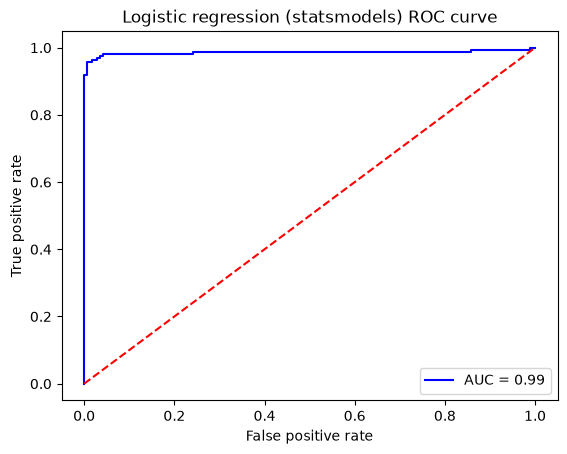

Accuracy score 0.969789
AUC score 0.986043
Kolmogorov-Smirnov statistic 0.950639


In [97]:
# statsmodels' Logit.predict returns probabilities of default
predicted_sm = model.predict(df_test[cols_to_use])

auc_score, accuracy_score, ks = calc_metrics(df_test['defaulter'], predicted_sm,
                                             title='Logistic regression (statsmodels) ROC curve')

print('Accuracy score %f' % accuracy_score)
print('AUC score %f' % auc_score)
print('Kolmogorov-Smirnov statistic %f' % ks)

## Logistic regression with scikit-learn

L1-penalised logistic regression (`C = 1000`, i.e. weak regularisation, `tol = 1e-6`) on the same predictors.

In [98]:
from sklearn import linear_model

trX, trY, teX, teY, predictors = make_test_train(df_train, df_test)
thisTrY = trY[:, 0]
thisTeY = teY[:, 0]

logistic_full = linear_model.LogisticRegression(penalty='l1', C=1000.0, tol=1e-6,
                                                solver='liblinear', random_state=42)
logistic_full.fit(trX, thisTrY)
lr_score = logistic_full.score(teX, thisTeY)

print('LogisticRegression score: %f' % lr_score)

LogisticRegression score: 0.969789


c:\Users\ayoub\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ayoub\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### Reduced set of predictors

Same model, restricted to the predictors that were significant in the statsmodels fit.

In [99]:
# smaller set of predictors, based on the p-values of the full logistic regression
cols_to_use = ['log_TA', 'NI_to_TA', 'Equity_to_TA', 'NPL_to_TL',
               'core_deposits_to_TA',
               'brokered_deposits_to_TA',
               'liquid_assets_to_TA'
              ] + ['term_spread', 'stock_mkt_growth']

X_train = df_train[cols_to_use]
Y_train = df_train['defaulter']
X_test = df_test[cols_to_use]
Y_test = df_test['defaulter']

logistic = linear_model.LogisticRegression(penalty='l1', C=1000.0, tol=1e-6,
                                           solver='liblinear', random_state=42)
logistic.fit(X_train, Y_train)
print('Test accuracy (reduced predictors): %f' % logistic.score(X_test, Y_test))

# coefficients of the fitted model
model_params = np.hstack((logistic.coef_[0], logistic.intercept_))
df_coeffs_LR = pd.DataFrame(data=model_params, index=cols_to_use + ['const'], columns=['coefficient'])
df_coeffs_LR

Test accuracy (reduced predictors): 0.963746


c:\Users\ayoub\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ayoub\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,coefficient
log_TA,-1.473226
NI_to_TA,-0.797123
Equity_to_TA,-1.884347
NPL_to_TL,0.338079
core_deposits_to_TA,-0.502668
brokered_deposits_to_TA,0.023561
liquid_assets_to_TA,-0.513416
term_spread,0.011348
stock_mkt_growth,0.026440
const,-0.093853


## Logistic regression with TensorFlow

In [100]:
# Setup inputs and expeced outputs for Logistic Regression using Tensorflow
cols = state_cols + MEV_cols
# inputs to Logistic Regression (via Tensorflow)
X_trainTf = df_train[cols].values
X_testTf = df_test[cols].values

# add constant columns to both
X_trainTf = np.hstack((np.ones((X_trainTf.shape[0], 1)), X_trainTf))
X_testTf = np.hstack((np.ones((X_testTf.shape[0], 1)), X_testTf))

# exepectd outputs:
y_trainTf = df_train.defaulter.astype('int').values.reshape(-1,1)
y_testTf = df_test.defaulter.astype('int').values.reshape(-1,1)

In [101]:
print('Unique values to predict:', np.unique(y_trainTf))
print('Number of samples to train on:', y_trainTf.shape[0])
print('Number of samples to test on:', y_testTf.shape[0])

Unique values to predict: [0 1]
Number of samples to train on: 641
Number of samples to test on: 331


In [102]:
# to make this notebook's output stable across runs
def reset_graph(seed=42):
    tf.reset_default_graph()
    tf.set_random_seed(seed)
    np.random.seed(seed)

In [103]:
def random_batch(X_train, y_train, batch_size):
    # sample a random mini-batch; reproducibility comes from the seed set in reset_graph()
    rnd_indices = np.random.randint(0, len(X_train), batch_size)
    X_batch = X_train[rnd_indices]
    y_batch = y_train[rnd_indices]
    return X_batch, y_batch

### Model

Placeholders `X` and `y`, a parameter vector `theta` (including the intercept), sigmoid output, log loss, plain gradient descent.

In [104]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()


reset_graph()
n_inputs = X_trainTf.shape[1]
learning_rate = 0.01
theta_init = tf.random_uniform([n_inputs, 1], -1.0, 1.0, seed=42)

X = tf.placeholder(tf.float32, shape=(None, n_inputs), name="X")
y = tf.placeholder(tf.float32, shape=(None, 1), name="y")
theta = tf.Variable(theta_init, name="theta")

logits = tf.matmul(X, theta)
y_proba = tf.sigmoid(logits)
loss = tf.losses.log_loss(y, y_proba, epsilon=1e-07)  # epsilon regularises the log
optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
training_op = optimizer.minimize(loss)

predictions = tf.cast(y_proba > 0.5, tf.float32)
accuracy = tf.reduce_mean(tf.cast(tf.equal(predictions, y), tf.float32))

init = tf.global_variables_initializer()

Instructions for updating:
non-resource variables are not supported in the long term




### Training

In [105]:
n_epochs = 1001
batch_size = 50
num_rec = X_trainTf.shape[0]
n_batches = int(np.ceil(num_rec / batch_size))

with tf.Session() as sess:
    sess.run(init)
    for epoch in range(n_epochs):
        for batch_index in range(n_batches):
            X_batch, y_batch = random_batch(X_trainTf, y_trainTf, batch_size)
            sess.run(training_op, feed_dict={X: X_batch, y: y_batch})
    y_proba_val = y_proba.eval(feed_dict={X: X_testTf, y: y_testTf})
    acc_test = accuracy.eval(feed_dict={X: X_testTf, y: y_testTf})

print('Test accuracy: %f' % acc_test)

Test accuracy: 0.966767


In [106]:
threshold = 0.5
y_pred = (y_proba_val >= threshold)
print('Predicted defaults on test set:', np.sum(y_pred))

Predicted defaults on test set: 162


precision:  0.9629629629629629
recall:  0.968944099378882
AUC score =  0.9853854585312387
KS_test =  0.945085860431129


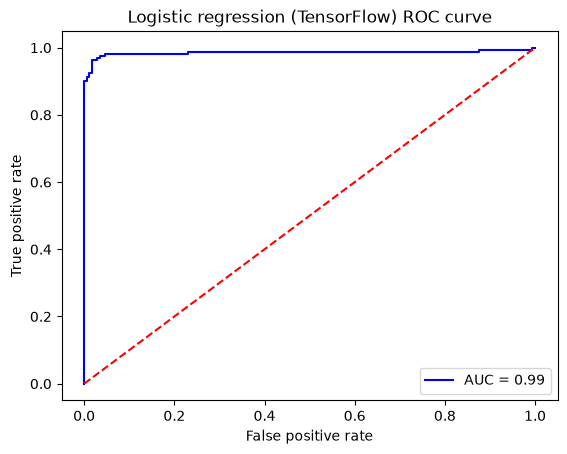

In [107]:
# precision, recall, AUC and KS on the test set
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_testTf, y_pred)
recall = recall_score(y_testTf, y_pred)
fpr, tpr, _ = metrics.roc_curve(y_testTf, y_proba_val, pos_label=1)
roc_auc = metrics.auc(fpr, tpr)
ks = np.max(tpr - fpr)

print('precision: ', precision)
print('recall: ', recall)
print('AUC score = ', roc_auc)
print('KS_test = ', ks)

plt.title('Logistic regression (TensorFlow) ROC curve')
plt.plot(fpr, tpr, 'b', label='AUC = %0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.show()

## Neural network with TensorFlow

In [108]:
cols = state_cols + MEV_cols
n_inputs = len(cols)

# inputs 
X_trainTf = df_train[cols].values
X_testTf = df_test[cols].values

# outputs 
y_trainTf = df_train['defaulter'].astype('int').values.reshape(-1,)
y_testTf = df_test['defaulter'].astype('int').values.reshape(-1,)

In [109]:
def neuron_layer(X, n_neurons, name, activation=None):
    with tf.name_scope(name):
        tf.set_random_seed(42)
        n_inputs = int(X.get_shape()[1])
        stddev = 2 / np.sqrt(n_inputs)
        init = tf.truncated_normal((n_inputs, n_neurons), stddev=stddev)
        W = tf.Variable(init, name="kernel")
        b = tf.Variable(tf.zeros([n_neurons]), name="bias")
        Z = tf.matmul(X, W) + b
        if activation is not None:
            return activation(Z)
        else:
            return Z

### Architecture

Two hidden layers (20 and 10 units, ReLU), a 2-unit output layer with softmax, cross-entropy loss on the probability of default, gradient descent.

In [110]:
n_hidden1 = 20
n_hidden2 = 10
n_outputs = 2  # failed / non-failed
learning_rate = 0.01

reset_graph()

X = tf.placeholder(tf.float32, shape=(None, n_inputs), name="X")
y = tf.placeholder(tf.float32, shape=(None), name="y")

hidden1 = neuron_layer(X, n_hidden1, name="hidden1", activation=tf.nn.relu)
hidden2 = neuron_layer(hidden1, n_hidden2, name="hidden2", activation=tf.nn.relu)
outputs = neuron_layer(hidden2, n_outputs, name="outputs", activation=None)

proba = tf.nn.softmax(outputs)
epsilon = 1e-07
proba = tf.clip_by_value(proba, epsilon, 1 - epsilon)
loss = -tf.reduce_mean(y * tf.log(proba[:, 1]) + (1.0 - y) * tf.log(1.0 - proba[:, 1]))
optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
training_op = optimizer.minimize(loss)

predictions = tf.cast(proba[:, 1] > 0.5, tf.float32)
accuracy = tf.reduce_mean(tf.cast(tf.equal(predictions, y), tf.float32))

init = tf.global_variables_initializer()

### Training

In [111]:
n_epochs = 400
batch_size = 50
num_rec = X_trainTf.shape[0]
n_batches = int(np.ceil(num_rec / batch_size))

with tf.Session() as sess:
    init.run()
    for epoch in range(n_epochs):
        for batch_index in range(n_batches):
            X_batch, y_batch = random_batch(X_trainTf, y_trainTf, batch_size)
            training_op.run(feed_dict={X: X_batch, y: y_batch})
    acc_test = accuracy.eval(feed_dict={X: X_testTf, y: y_testTf})

print('Test accuracy: %f' % acc_test)

Test accuracy: 0.975831
